In [7]:
!pip install -q kaggle

In [8]:
import os

# Replace with your actual Kaggle username and key
os.environ['KAGGLE_USERNAME'] = 'your_username'
os.environ['KAGGLE_KEY'] = 'your_api_key'

In [9]:
# Download dataset
!kaggle datasets download -d fedesoriano/cirrhosis-prediction-dataset -q

# Extract it
import zipfile

with zipfile.ZipFile("cirrhosis-prediction-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/cirrhosis-prediction-dataset
License(s): copyright-authors
Dataset ready!


In [10]:
import pandas as pd

df = pd.read_csv("cirrhosis.csv")
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [11]:
# First, we import all the necessary libraries
# These help us handle data, visualize it, and build models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [13]:
df.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [14]:
# Check for missing values
print(df.isnull().sum())

# Fill missing values with median (works well for medical data)
df.fillna(df.median(numeric_only=True), inplace=True)

# If there are categorical columns, we convert them into numbers
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

print("Data cleaned successfully!")

ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64
Data cleaned successfully!


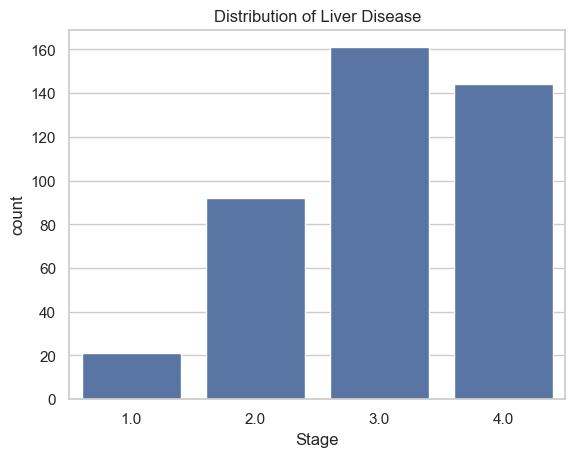

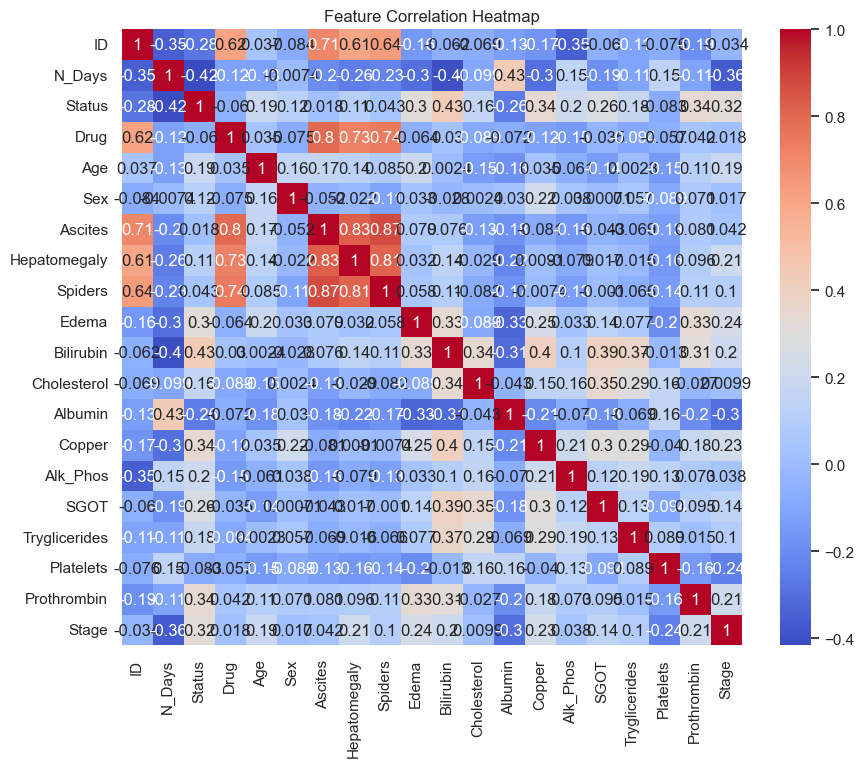

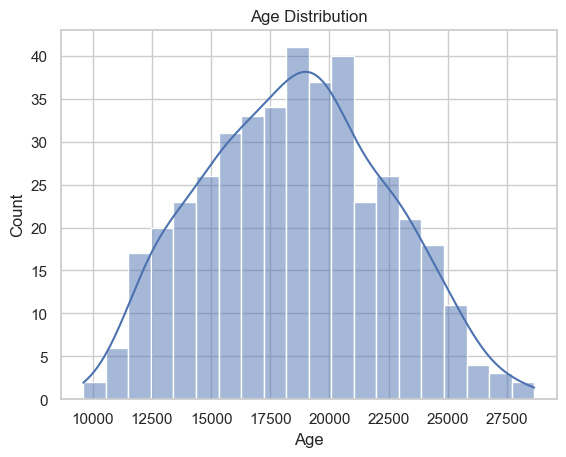

In [15]:
# Set a clean style for graphs
sns.set(style="whitegrid")

# Distribution of target variable (Disease / No Disease)
plt.figure()
sns.countplot(x=df.iloc[:, -1])
plt.title("Distribution of Liver Disease")
plt.show()

# Correlation heatmap to understand relationships
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Example: Age distribution
plt.figure()
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

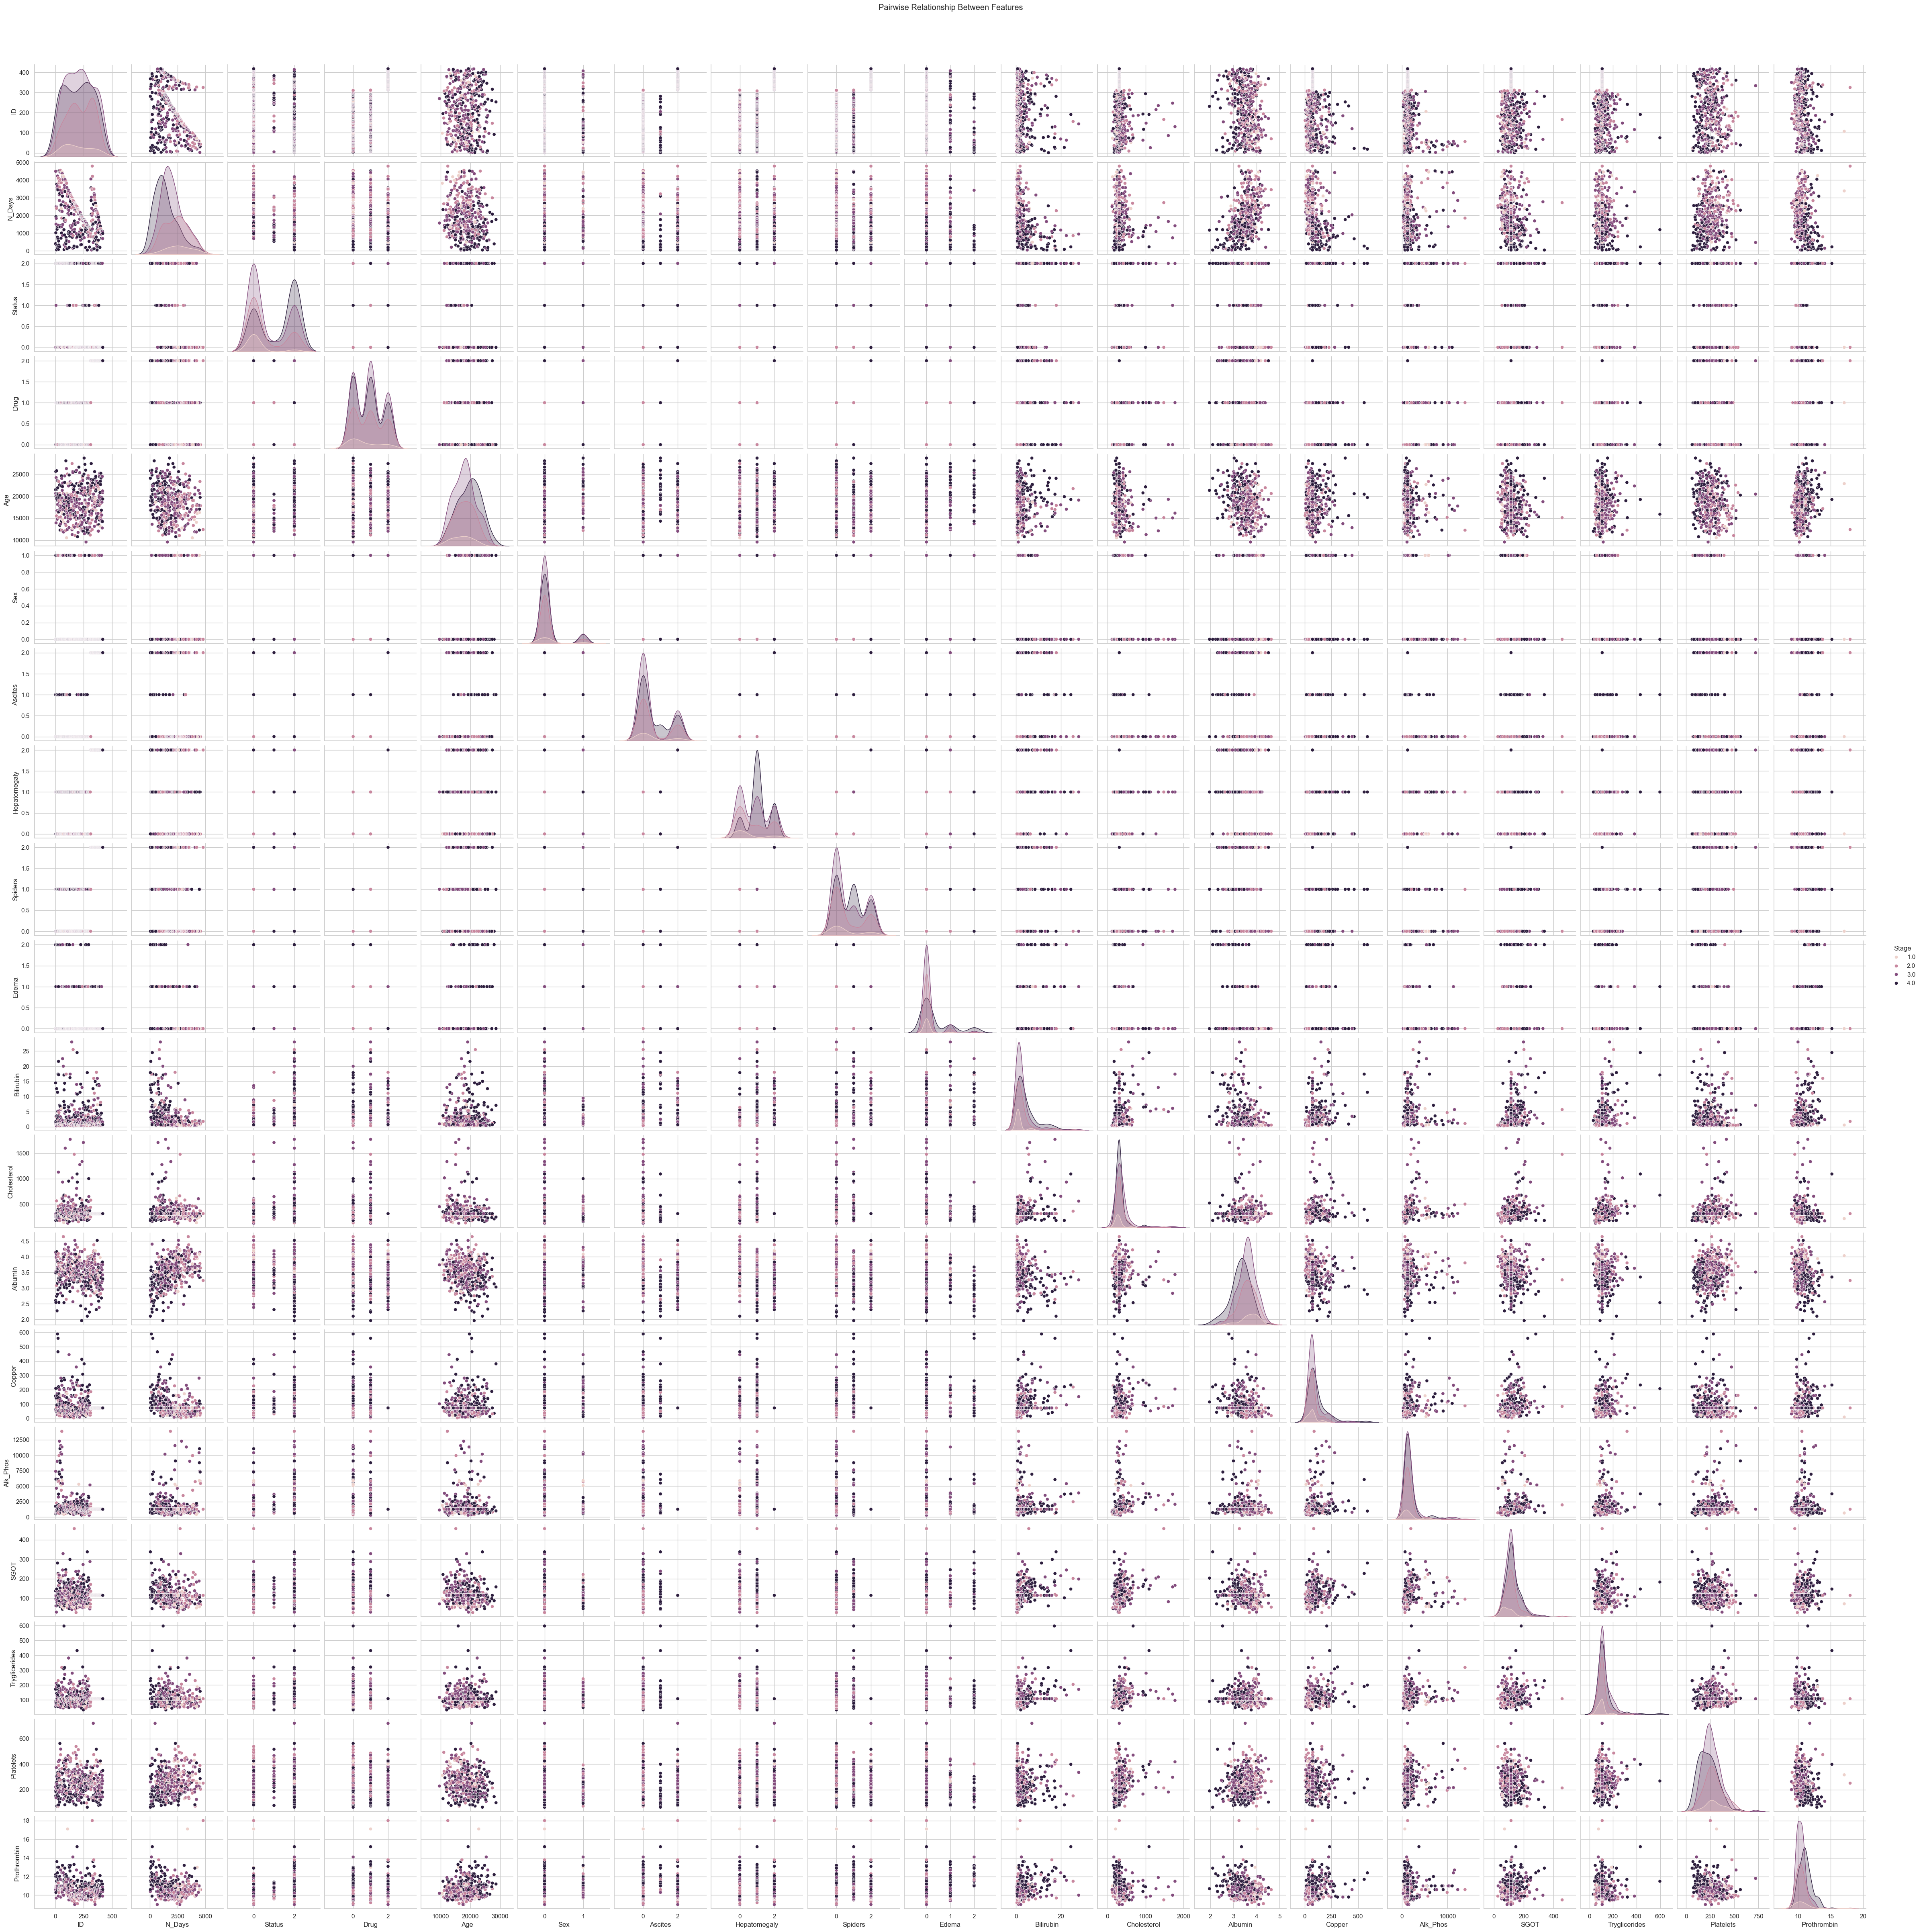

In [24]:
# This plot helps us see relationships between multiple features at once

# Pairplot 
sns.pairplot(df, hue=df.columns[-1])

plt.suptitle("Pairwise Relationship Between Features", y=1.02)
plt.show()

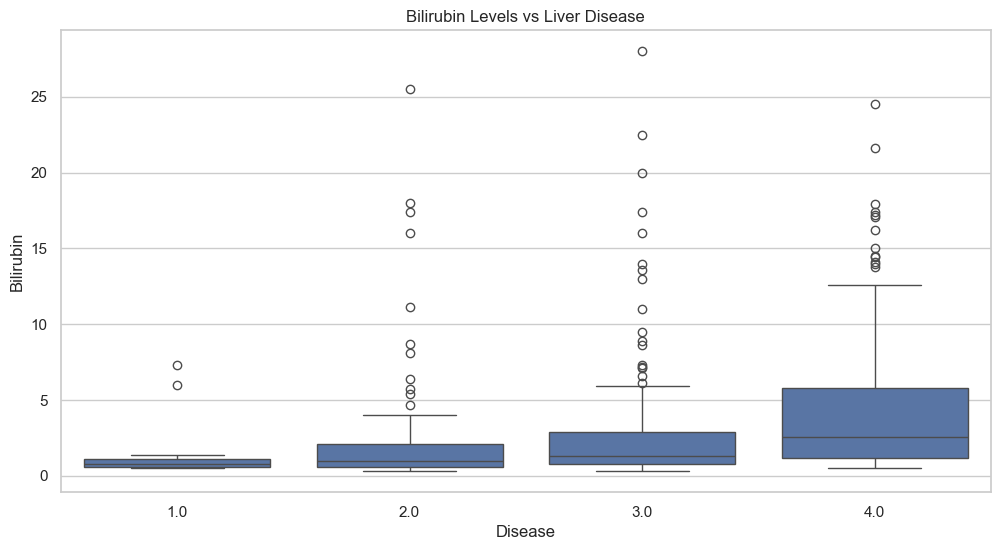

In [23]:
# Here we compare important features against disease condition

plt.figure(figsize=(12,6))

sns.boxplot(x=df.iloc[:, -1], y=df['Bilirubin'])

plt.title("Bilirubin Levels vs Liver Disease")
plt.xlabel("Disease")
plt.ylabel("Bilirubin")
plt.show()

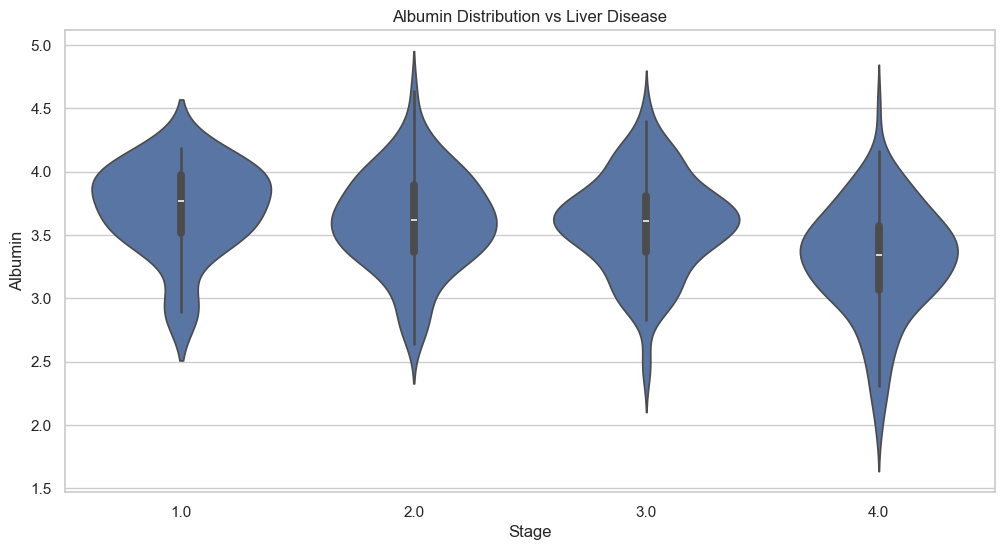

In [25]:
# Violin plot gives more detail than boxplot
plt.figure(figsize=(12,6))

sns.violinplot(x=df.iloc[:, -1], y=df['Albumin'])

plt.title("Albumin Distribution vs Liver Disease")
plt.show()

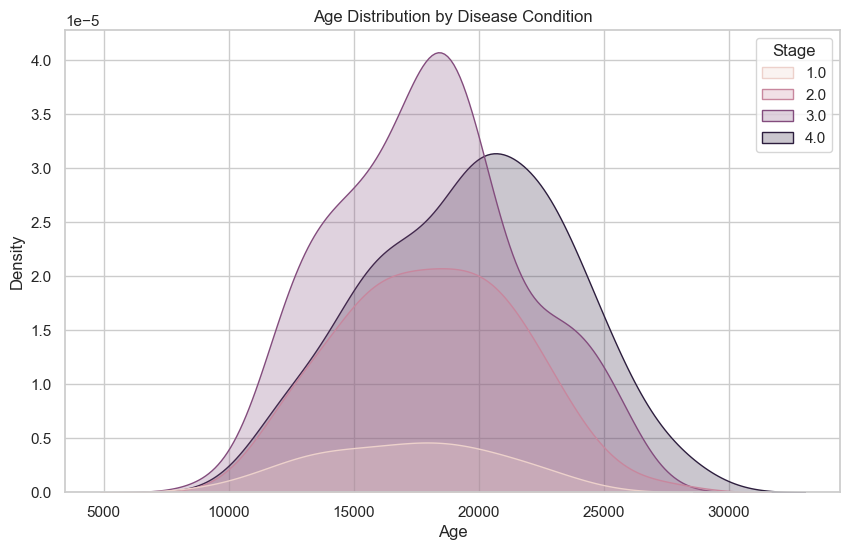

In [26]:
# KDE plot shows smooth probability distribution

plt.figure(figsize=(10,6))

sns.kdeplot(data=df, x="Age", hue=df.columns[-1], fill=True)

plt.title("Age Distribution by Disease Condition")
plt.show()

In [16]:
# Separating features (X) and target (y)
# Assuming last column is the target variable

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Standardizing the data 
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [17]:
# Splitting data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split into training and testing sets.")

Data split into training and testing sets.


In [18]:
# Logistic Regression model (simple and effective)

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5238095238095238
[[ 1  2  0  0]
 [ 1  3  9  3]
 [ 0  6 19  9]
 [ 1  1  8 21]]
              precision    recall  f1-score   support

         1.0       0.33      0.33      0.33         3
         2.0       0.25      0.19      0.21        16
         3.0       0.53      0.56      0.54        34
         4.0       0.64      0.68      0.66        31

    accuracy                           0.52        84
   macro avg       0.44      0.44      0.44        84
weighted avg       0.51      0.52      0.51        84



In [19]:
# Random Forest (more powerful model)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5119047619047619
[[ 0  1  2  0]
 [ 0  2 11  3]
 [ 0  4 23  7]
 [ 0  0 13 18]]
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         3
         2.0       0.29      0.12      0.17        16
         3.0       0.47      0.68      0.55        34
         4.0       0.64      0.58      0.61        31

    accuracy                           0.51        84
   macro avg       0.35      0.35      0.33        84
weighted avg       0.48      0.51      0.48        84



C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

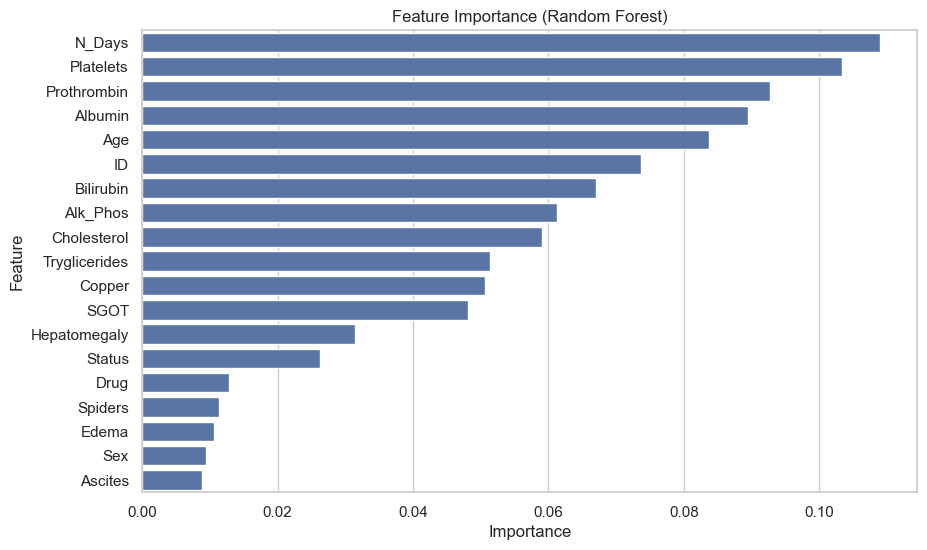

In [20]:
# This shows which features are most important

importances = rf_model.feature_importances_
feature_names = df.columns[:-1]

# Creating a DataFrame for better visualization
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plotting
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [21]:
print("Top Important Features:")
print(feat_df.head())

print("\nDataset Shape:", df.shape)
print("Class Distribution:\n", y.value_counts())

Top Important Features:
        Feature  Importance
1        N_Days    0.108983
17    Platelets    0.103289
18  Prothrombin    0.092733
12      Albumin    0.089449
4           Age    0.083725

Dataset Shape: (418, 20)
Class Distribution:
 Stage
3.0    161
4.0    144
2.0     92
1.0     21
Name: count, dtype: int64
